In [1]:
%matplotlib inline  
# Display plots directly below the cell.Without it, plots may not appear automatically.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats  #statistical functions

#use seaborn plotting defualts
import seaborn as sns
sns.set()

Create dataset

In [5]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.60)
# 50 data points, 2 classes(Class 0 and Class 1), random_state=0 means ensures same random points every time, cluster_std = 0.60 means the cluster spread, smaller value -> tight clusters, large value -> scattered clusters

In [6]:
print(X)

[[ 1.41281595  1.5303347 ]
 [ 1.81336135  1.6311307 ]
 [ 1.43289271  4.37679234]
 [ 1.87271752  4.18069237]
 [ 2.09517785  1.0791468 ]
 [ 2.73890793  0.15676817]
 [ 3.18515794  0.08900822]
 [ 2.06156753  1.96918596]
 [ 2.03835818  1.15466278]
 [-0.04749204  5.47425256]
 [ 1.71444449  5.02521524]
 [ 0.22459286  4.77028154]
 [ 1.06923853  4.53068484]
 [ 1.53278923  0.55035386]
 [ 1.4949318   3.85848832]
 [ 1.1641107   3.79132988]
 [ 0.74387399  4.12240568]
 [ 2.29667251  0.48677761]
 [ 0.44359863  3.11530945]
 [ 0.91433877  4.55014643]
 [ 1.67467427  0.68001896]
 [ 2.26908736  1.32160756]
 [ 1.5108885   0.9288309 ]
 [ 1.65179125  0.68193176]
 [ 2.49272186  0.97505341]
 [ 2.33812285  3.43116792]
 [ 0.67047877  4.04094275]
 [-0.55552381  4.69595848]
 [ 2.16172321  0.6565951 ]
 [ 2.09680487  3.7174206 ]
 [ 2.18023251  1.48364708]
 [ 0.43899014  4.53592883]
 [ 1.24258802  4.50399192]
 [ 0.00793137  4.17614316]
 [ 1.89593761  5.18540259]
 [ 1.868336    0.93136287]
 [ 2.13141478  1.13885728]
 

In [7]:
print(y)

[1 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 0 0 1 0 1 0 0 0 0 1 1
 0 1 0 1 0 1 1 0 1 1 0 1 0]


Visualize data

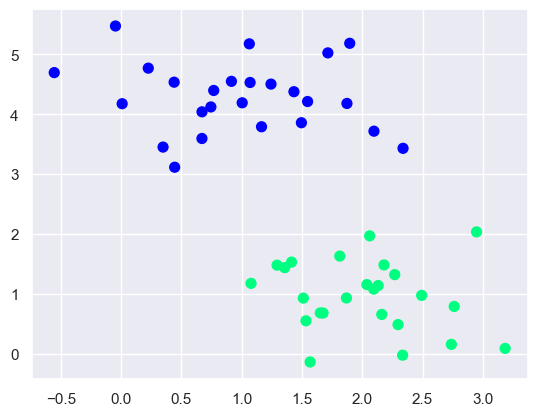

In [9]:
plt.scatter(X[:,0], X[:,1], c=y, s=50, cmap='winter')
# X[:,0] means x-axis
# X[:1] means y-axis
# c=y means color based on class => class 0 is blue, class 1 is green
# s=50 means point size

Train SVM

In [10]:
from sklearn.svm import SVC  
# Support Vector Classifier
model = SVC(kernel='linear', C=1)
# use straight line separator -> decision boundary: y = mx + b
# C=1 is the regularization parameter, it controls margin width vs classification error
model.fit(X, y)
# SVM learns best separating line between classes

SVC(C=1, kernel='linear')

|Decision Boundary Function
Draws:

1. Decision boundary
2. margins
3. support vectors

In [ ]:
def plot_svc_decision_function(moedl, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    # get graph boundaries
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    # creates 30 evenly spaced x-values. and 30 evenly spaced y values
    x = np.linspace(xlim[0], xlim[1], 30) # start, stop, number_of_points --> It creates equally spaced points.
    y = np.linspace(ylim[0], ylim[1], 30)

    # Each row corresponds to a y-value.
    # Each column corresponds to an x-value.
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    # ravel() means to convert the matrix into 1D array
    # vstack means stacks vertically
    # .T means transpose , here the rows have become the columns
    P = model.decision_function(xy).reshape(X.shape)  # to calculate how far is the decision boundary
    
    # what is a contour ?
    # imagine a height map , height = 0, height =1, height = 2
    # contour draws curves conencting equal values
    # contour has levels = -1,0,1 which means P=-1, P=0, P=1 these corresponds to margin , boundary, margin
    # deciosn boundary of SVM is f(x)=w.x+b, and support vectors lie on +, -1
    ax.contour(X, Y, P, colors='k', levels=[-1,0,1], alpha=0.5, linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:,1], s=300, linewidth=1, facecolors='none')  # facecolors='none' means create hollow circles

    # restores original graph boundaries, because contour plotting sometimes changes axes automatically
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)





Meshgrid meaning:
x = [1,2,3]
y = [10,20,30]

Mesh grid creates:
(1,10) (1,20) (1,30)

(2,10) (2,20) (2,30)

(3,10) (3,20) (3,30)
Every possible combination.


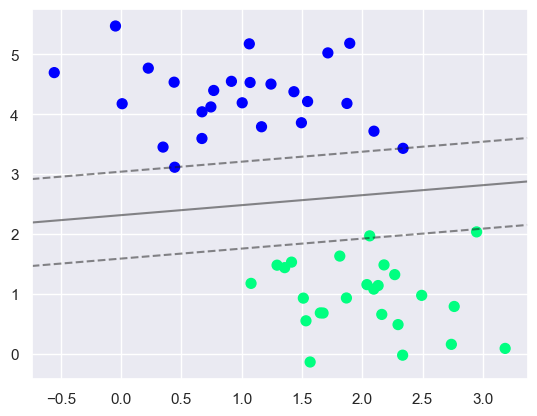

In [20]:
plt.scatter(X[:,0],X[:,1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model)

The importance of support vectors


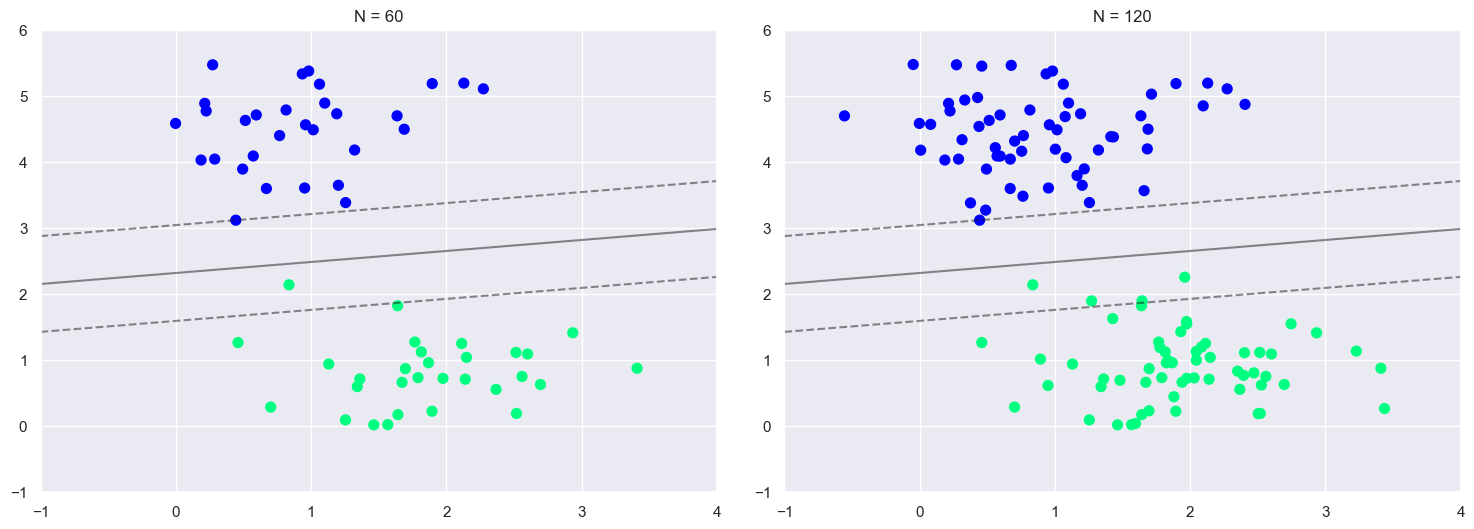

In [21]:
#"What happens to the decision boundary when we add more training points?"
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2, random_state=0, cluster_std=0.60)

    # suppose plot_svc(60) then X=X[:60] that means only first 60 points are used
    X=X[:N]
    y=y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    # here we are going to compare 60 vs 120 data points, C = 10000000000
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

Working with almost linearly separable dataset

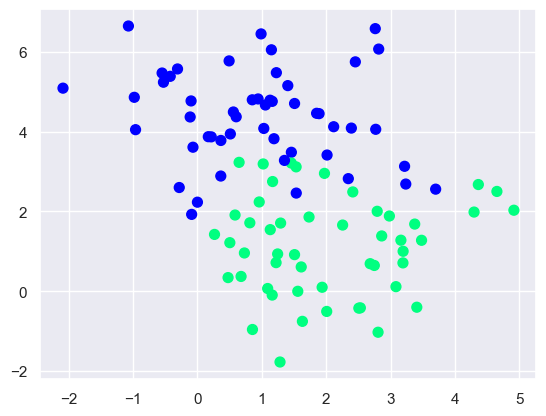

In [ ]:
X, y = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)
# Higher standard deviation.
# Clusters become more spread out.
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')

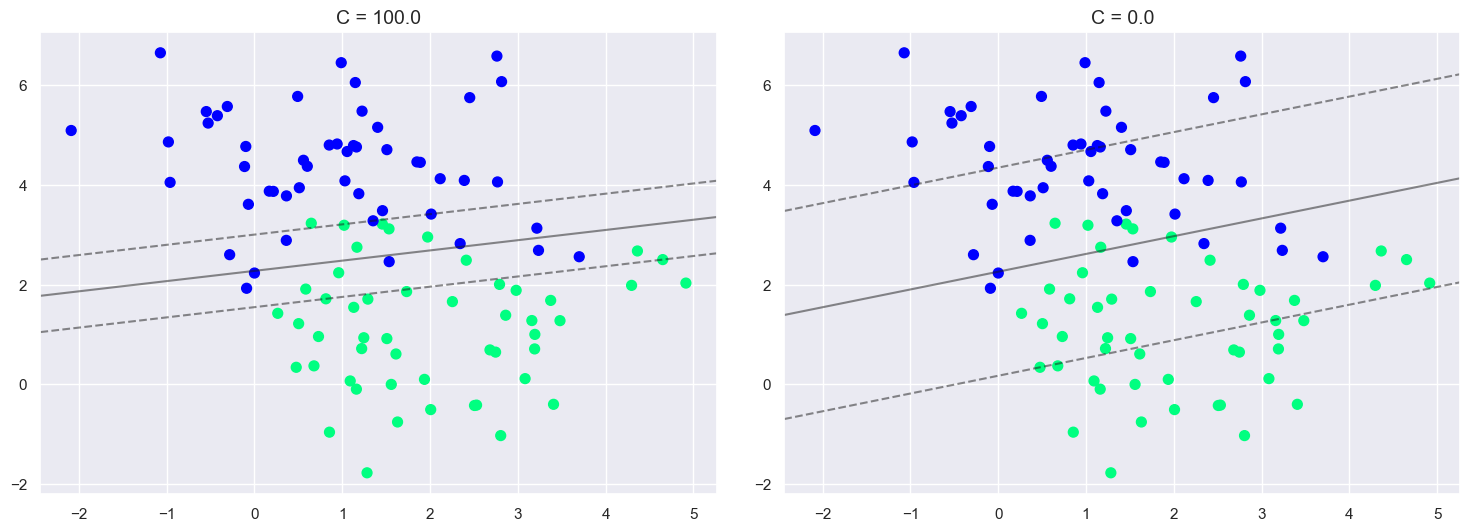

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.01]):  # two svms are trainded, one with large penalty for mistakes i.e smaller margin
    # second is wider margin that means some i=mistakes are okay
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

# Large C :
Low Bias
High Variance
Risk of Overfitting

# Small C:
Higher Bias
Lower Variance
Better Generalization